<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/information-bottleneck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Information Bottleneck Theory of Deep Learning

This was originally an experiment into replicating the gradient mean/stddev observations reported by the following paper, while also providing an example of how to use the toolkit for arbitrary experiments:

* Shwartz-Ziv, R., Tishby, N. (2017). Opening the Black Box of Deep Neural Networks via Information. ArXiv. https://arxiv.org/abs/1703.00810

They suggested that training should show two distinct phases:
1. _prediction improvement_
  * The first phase is the most important one and also the most rapid, where the model learns to improve its prediction accuracy.
2. _representational compression_
  * In this second phase, the model optimises its internal representation, "compressing" it by learning to better attend just to the features that matter.
  * Secondly, while the important features becomes "compressed", the unimportant features supposedly become "dispersed" - spreading the distribution of their representations, and improving generalisation in the process.

They claim that the second phase occurs because of the random walk that SGD produces around the optimal point. It would even seem that their findings were a prelude to a later work:
* Power, A., Burda, Y, et al (2022). Grokking: Generalization Beyond Overfitting on Small Algorithmic Datasets. https://arxiv.org/abs/2201.02177

A good walk-through of the findings is also covered in the following video:
* Tishby, N. The Information Bottleneck Theory of \[simple\] Deep Learning. https://www.youtube.com/watch?v=Zb9-1PZoAj4

**Difficulty Reproducing**

However, it turns out that it's quite difficult to reproduce their results and there's quite some controversy surrounding their claims, for example:
* Orhan, E. (2017). No, information bottleneck (probably) doesn’t open the “black-box” of deep neural networks [Blog post]. https://severelytheoretical.wordpress.com/2017/09/28/no-information-bottleneck-probably-doesnt-open-the-black-box-of-deep-neural-networks/
* Liventsev, V., & Kupchenko, L. (2018). Opening the Black Box of Deep Neural Networks with more information [Blog post]. https://vadim.me/publications/blackbox/
* Saxe et al (2018). On the Information Bottleneck Theory of Deep Learning. ICLR 2018.
* Noshad, M., Zeng, Y., Hero, A. O (2018). Scalable Mutual Information Estimation using Dependence Graphs. ArXiv. https://arxiv.org/abs/1801.09125

In the below I have attempted to use the approach taken by Liventsev & Kupchenko for the data setup and model architecture. However, it does not reproduce the result of showing separate phases within the mean and stddev of gradients. Liventsev & Kupchenko's own experiments only reproduced the mutual information plots, which I have not attempted here.

In any case, I leave this here as an example.

In [3]:
# Install Training Instrumentation Toolkit
import os
import sys
if not os.path.isdir('training-instrumentation-toolkit'):
  !git clone https://github.com/malcolmlett/training-instrumentation-toolkit.git
sys.path.append('training-instrumentation-toolkit')

# Imports
import train_instrumentation as tinstr
import keras
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras import layers, models, datasets, optimizers, metrics
import numpy as np
import matplotlib.pyplot as plt
import math
import sklearn
from scipy.ndimage import gaussian_filter1d

## Data collection and visualisation code
The following code is generic and re-usable across most models.

## Instrumented Training Run
We'll use a simple binary classification problem, against the commonly used "circles" dataset.

We won't go into details about the various options for instrumentation in this notebook. See the _Instrumentation_ notebook for that.

In [4]:
# benefit is on order of 159ms/epoch with _norm() vs 172ms/epoch with tf.norm()
def _norm(x):
  """
  More efficient equivalent of tf.norm() that directly computes the
  sqrt of the sum of squares. This is probably more efficient because it's hard-coded to compute the norm
  in just one way.
  """
  return tf.math.sqrt(tf.reduce_sum(tf.square(x)))

class GradientNormCollector(tinstr.BaseGradientCallback):
    """
    Collects the components needed to calculated gradient means and std.devs normalized by the L2-norm of the weights,
    as used by Shwartz-Ziv & Tishby.
    Only collects per-epoch asd this is intended to be used over very long training runs.

    Gradients a "normalized" mean and stddev of gradients according to the following equations. This enables us to examine
    the gradient distributions independent of the absolute scale of weights.


                                    ||E[gradients]||_2
    Normalized Mean Gradient Norm = ------------------
                                      ||weights||_2


                                    ||STD[gradients]||_2
    Normalized STD Gradient Norm = ---------------------
                                       ||weights||_2

    where:
      - E[gradients] = element-wise mean of stochastic gradients over mini-batches
      - STD[gradients] = element-wise std.dev of stochastic gradients over mini-batches
      - ||E[gradients]||_2 = L2 norm (euclidean) of the mean gradient
      - ||weights||_2 = L2 norm of the weight matrix at the end of each epoch

    As we're taking samples only at the end of the epoch we'll average the gradients over the course of the epoch.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.epoch_gradient_means = []  # list (by-epoch) of list (by-variable) of scalar L2-norms of element-wise means of gradients
        self.epoch_gradient_stddevs = []  # list (by-epoch) of list (by-variable) of scalar L2-norms of element-wise stddevs of gradients
        self.epoch_weight_norms = []  # list (by-epoch) of list (by-variable) of scalar L2-norms of element-wise means of variables
        self._gradient_accumulator = tinstr.PerEpochAccumulatorStrategy()  # raw gradients
        self._gradient2_accumulator = tinstr.PerEpochAccumulatorStrategy()  # gradients squared

    @property
    def normalized_stats(self):
        """
        The scalar normalized means and stdevs of the gradients of each variable over the course of each
        epoch, as per the equations documented above.
        Returns:
          (grad_means, grad_stddevs), where:
            - grad_means - array (epoch, variable) of normalized gradient means
            - grad_stddevs - array (epoch, variable) of normalized gradient stddevs
        """
        grad_mean_norms, grad_stddev_norms, weight_norms = self.collected_norms
        normalized_grad_means = grad_mean_norms / weight_norms
        normalized_grad_stddevs = grad_stddev_norms / weight_norms
        return normalized_grad_means, normalized_grad_stddevs

    @property
    def normalized_stats_by_layer(self):
        """
        Selects the stats of just the main weights of each layer.
        Blindly assumes that the first variable in each layer is the main weights.
        Any layers that don't have variables are returned as None.
        Returns:
          list (by-layer) of pandas DataFrame with shape (epochs, 2) with columns containing, respectively:
            - [0] normalized mean gradient norm
            - [1] normalized stddev gradient norm
        """
        # results by trainable variable
        means, stddevs = self.normalized_stats

        # determine filter
        var_indices = tinstr.trainable_variable_indices_by_layer(self.model)
        num_layers = len(self.model.layers)
        filter = [var_indices[l_idx][0] for l_idx in range(num_layers) if var_indices[l_idx]]

        # apply filter
        means = means[:, filter]
        stddevs = stddevs[:, filter]
        return means, stddevs

    @property
    def normalized_stats_layers(self):
      """
      Layer indices for layers returned by `normalized_stats_by_layer`
      """
      var_indices = tinstr.trainable_variable_indices_by_layer(self.model)
      num_layers = len(self.model.layers)
      return [l_idx for l_idx in range(num_layers) if var_indices[l_idx]]

    @property
    def collected_norms(self):
        """
        Returns
          (grad_means, grad_stddevs, weights), where:
            - grad_means - array (epoch, variable) of scalar L2-norms of element-wise means of gradients
            - grad_stddevs - array (epoch, variable) of scalar L2-norms of element-wise stddevs of gradients
            - weights - array (epoch, variable) of scalar L2-norms of element-wise means of variables
        """
        return np.array(self.epoch_gradient_means),\
            np.array(self.epoch_gradient_stddevs),\
            np.array(self.epoch_weight_norms)

    def on_train_end(self):
        del self._gradient_accumulator
        del self._gradient2_accumulator

    def on_epoch_end(self, epoch, loss, gradients, trainable_variables, activations, output_gradients):
        grad_ew_means = self._gradient_accumulator.mean  # element-wise means, per variable
        grad2_ew_means = self._gradient2_accumulator.mean  # element-wise means of squares, per variable

        grad_mean_norms, grad_std_norms, w_norms = self._compute_stats(
            trainable_variables, grad_ew_means, grad2_ew_means)

        self.epoch_gradient_means.append(grad_mean_norms)
        self.epoch_gradient_stddevs.append(grad_std_norms)
        self.epoch_weight_norms.append(w_norms)

    def on_train_batch_end(self, batch, loss, gradients, trainable_variables, activations, output_gradients):
        self._gradient_accumulator.accumulate(batch, gradients)
        self._gradient2_accumulator.accumulate(batch, [tf.square(g) for g in gradients])

    @tf.function
    def _compute_stats(self, variables, grad_ew_means_per_var, grad2_ew_means_per_var):
        """
        Uses the following following form for calculating stddev:
          std(X) = sqrt( E[X^2] - (E[X])^2 )
        where:
          E[X] = mean of X
        """
        def _compute_std(grad_ew_means, grad2_ew_means):
            return tf.sqrt(tf.maximum(0.0, grad2_ew_means - grad_ew_means ** 2))  # element-wise stddev

        grad_mean_norms = [_norm(grad_ew_means) for grad_ew_means in grad_ew_means_per_var]
        grad_std_norms = [_norm(_compute_std(grad_ew_means, grad2_ew_means2))
                          for grad_ew_means, grad2_ew_means2 in zip(grad_ew_means_per_var, grad2_ew_means_per_var)]
        w_norms = [_norm(var) for var in variables]
        return grad_mean_norms, grad_std_norms, w_norms

In [5]:
# plus a couple of helper functions for later
def layer_indices_of_interest(model):
  def _is_layer_of_interest(layer):
    return "dense" in layer.name or "conv" in layer.name
  return [l_idx for l_idx, layer in enumerate(model.layers) if _is_layer_of_interest(layer)]

def trainable_variable_indices_of_interest(model):
  """
  Picks just the 'weights' or 'kernel' variables from layers of interest
  (any of the normal trainable layers that have weights, excluding things like BatchNormalization).
  Returns:
    list of indices relative to the model.trainable_variables list
  """
  filtered_layer_indices = layer_indices_of_interest(model)
  var_indices_by_layer = tinstr.trainable_variable_indices_by_layer(model)
  return [var_indices_by_layer[l_idx][0] for l_idx in filtered_layer_indices]

In [6]:
# Helper functions for plotting
def plot_raw_norms(cb: GradientNormCollector, smoothness=None, xlog=True):
  """
  Filters on just the layers of interest, excluding any gradients from layers like BatchNorm.
  """
  filtered_variable_indices = trainable_variable_indices_of_interest(cb.model)
  grad_mean_norms, grad_std_norms, weight_norms = cb.collected_norms
  grad_mean_norms = grad_mean_norms[:, filtered_variable_indices]
  grad_std_norms = grad_std_norms[:, filtered_variable_indices]
  weight_norms = weight_norms[:, filtered_variable_indices]
  series_names = [cb.model.layers[l_idx].name for l_idx in layer_indices_of_interest(cb.model)]

  # apply smoothing
  if smoothness:
    grad_mean_norms = gaussian_filter1d(grad_mean_norms, sigma=smoothness, axis=0)
    grad_std_norms = gaussian_filter1d(grad_std_norms, sigma=smoothness, axis=0)
    weight_norms = gaussian_filter1d(weight_norms, sigma=smoothness, axis=0)

  plt.figure(figsize=(15,3), layout='constrained')

  plt.subplot(1,3,1)
  plt.title("gradient mean norms")
  plt.plot(grad_mean_norms)
  if xlog:
    plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('epoch')
  plt.ylabel('norm')

  plt.subplot(1,3,2)
  plt.title("gradient stddev norms")
  plt.plot(grad_std_norms)
  if xlog:
    plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('epoch')
  plt.ylabel('norm')

  plt.subplot(1,3,3)
  plt.title("weight norms")
  plt.plot(weight_norms, label=series_names)
  if xlog:
    plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('epoch')
  plt.ylabel('norm')
  plt.legend()

  plt.show()

def plot_gradient_norms(cb: GradientNormCollector, smoothness=None, xlog=True):
  """
  Filters on just the layers of interest, excluding any gradients from layers like BatchNorm.
  """
  filtered_variable_indices = trainable_variable_indices_of_interest(cb.model)
  means, stddevs = cb.normalized_stats
  means = means[:, filtered_variable_indices]
  stddevs = stddevs[:, filtered_variable_indices]

  # apply smoothing
  if smoothness:
    means = gaussian_filter1d(means, sigma=smoothness, axis=0)
    stddevs = gaussian_filter1d(stddevs, sigma=smoothness, axis=0)

  plt.figure(figsize=(15,3), layout='constrained')

  plt.subplot(1,2,1)
  plt.title("gradient means")
  plt.plot(means)
  if xlog:
    plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('epoch')
  plt.ylabel('normalized gradient mean')

  plt.subplot(1,2,2)
  plt.title("gradient stddevs")
  plt.plot(stddevs)
  if xlog:
    plt.xscale('log')
  plt.yscale('log')
  plt.xlabel('epoch')
  plt.ylabel('normalized gradient stddev')

  plt.show()

## Dataset and Model

In [7]:
# The "more complicated decision function" dataset from https://vadim.me/publications/blackbox/,
# with the following modifications:
#  - changed to one-hot-encoded output suitable for CE loss (also experimented exactly as per the blog post with no difference in the outcome)
X = np.random.randint(5, size=(1000, 12)) - 1
y = np.sum(X[:,2::2] * X[:,3::2]) - X[:,0] * X[:,0]
y = y + np.random.normal(size=1000, scale=0.2) > np.mean(y)
y = y * 1
Y = y.reshape(-1, 1)
print("Training data:")
print(f" X:             {X.shape} in range {np.min(X)} .. {np.max(X)}")
print(f" Y_complicated: {Y.shape} in range {np.min(Y)} .. {np.max(Y)}")

Training data:
 X:             (1000, 12) in range -1 .. 3
 Y_complicated: (1000, 1) in range 0 .. 1


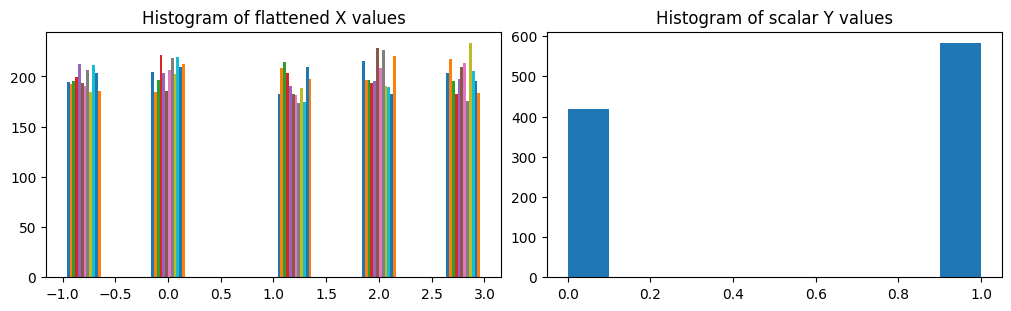

In [12]:
plt.figure(figsize=(10,3), layout='constrained')

plt.subplot(1,2,1)
plt.title("Histogram of flattened X values")
plt.hist(X)

plt.subplot(1,2,2)
plt.title("Histogram of scalar Y values")
plt.hist(Y)

plt.show()

In [13]:
# The "Experiment 2: As close to Tishby setup as possible" model from https://vadim.me/publications/blackbox/,
# with the following modifications:
#  - converted from PyTorth to TensorFlow
#  - not using their custom BufferedSequential as we've got that solved a different way with the toolkit
#  - last last layer changed from 1-unit tanh to 2-unit softmax (for CE loss, also experimented exactly as per the blog post with no difference in the outcome)
def tishby_model():
  model = tf.keras.Sequential([
      layers.Input((12,)),
      layers.Dense(10, activation='tanh'),  # 12 -> 10
      layers.Dense(7, activation='tanh'),  # 10 -> 7
      layers.Dense(5, activation='tanh'),  # 7 -> 5
      layers.Dense(4, activation='tanh'),  # 5 -> 4
      layers.Dense(3, activation='tanh'),  # 4 -> 3
      layers.Dense(2, activation='softmax')   # 3 -> 2  # modification: converted to softmax output
  ])
  return model
tishby_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │             130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │              77 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              15 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │               8 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 294 (1.15 KB)

 Trainable params: 294 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train model using SGD and same learning rate from https://vadim.me/publications/blackbox/.
# Note that I suspect it's important to use SGD over Adam if you want to replicate the findings.
# Adam has path-smoothing mechanisms that would likely reduce the supposed effect of the gradient
# stddev increasing during the second phase. However, even with SGD I'm still unable to replicate that result,
# and frankly, it seems like an odd claim.

gradient_norms = GradientNormCollector()

model = tishby_model()
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2), loss='ce', metrics=['accuracy'])
history = tinstr.fit(model, X, Y, batch_size=101, epochs=1000, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), gradient_norms, tinstr.HistoryStats()])

Epoch   100 - 187.63ms/epoch: accuracy: 1.0000  loss: 0.0008  
Epoch   200 - 136.51ms/epoch: accuracy: 1.0000  loss: 0.0004  
Epoch   300 - 145.69ms/epoch: accuracy: 1.0000  loss: 0.0003  
Epoch   400 - 137.64ms/epoch: accuracy: 1.0000  loss: 0.0002  
Epoch   500 - 133.50ms/epoch: accuracy: 1.0000  loss: 0.0002  
Epoch   600 - 137.15ms/epoch: accuracy: 1.0000  loss: 0.0001  
Epoch   700 - 137.66ms/epoch: accuracy: 1.0000  loss: 0.0001  
Epoch   800 - 144.02ms/epoch: accuracy: 1.0000  loss: 0.0001  
Epoch   900 - 202.30ms/epoch: accuracy: 1.0000  loss: 0.0001  
Epoch  1000 - 170.07ms/epoch: accuracy: 1.0000  loss: 0.0001  


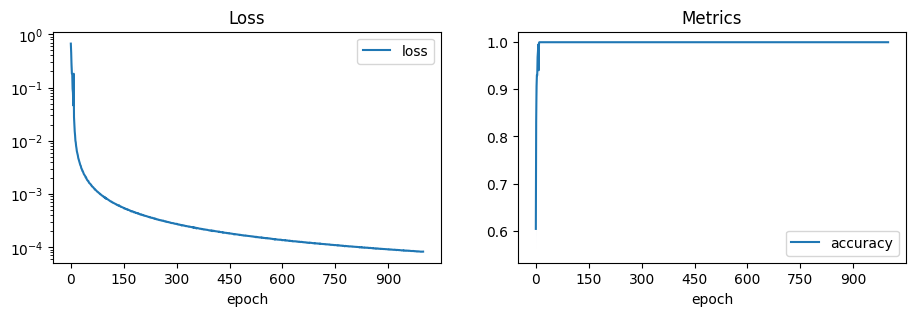

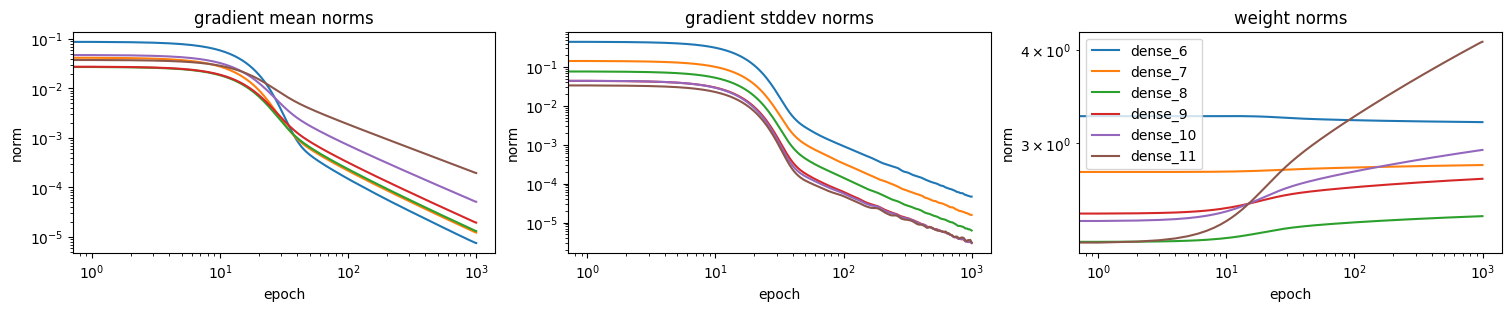

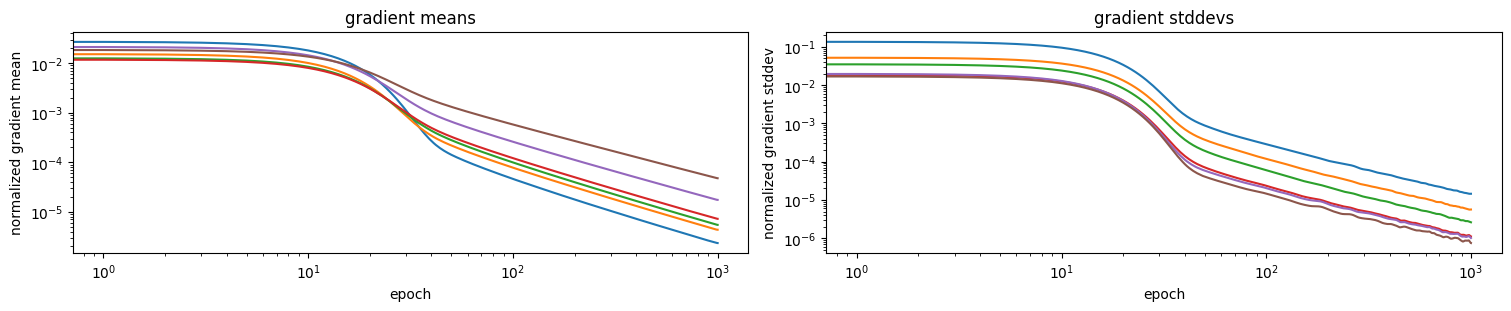

In [16]:
tinstr.plot_train_history(history)
plot_raw_norms(gradient_norms, smoothness=10)
plot_gradient_norms(gradient_norms, smoothness=10)

## Appendix: Checking the functionality of the GradientNormCollector callback

In [17]:
# validating the custom _norm() function
a = tf.random.normal((100,1000))
n1 = tf.norm(a)
n2 = _norm(a)
print(f"{n1=}, {n2=}")

@tf.function
def oob_norm_fn(x):
  return tf.norm(x)

@tf.function
def new_norm_fn(x):
  return _norm(x)

def test_fn(fn, iterations, shape=(100, 1000)):
  start = tf.timestamp()
  res = 0.0
  for i in range(iterations):
    x = tf.random.normal(shape)
    res = res + fn(a)
  duration = (tf.timestamp() - start).numpy()
  res = res.numpy()
  return res, duration

print(f"Measuring...")
r1, d1 = test_fn(oob_norm_fn, 2000)
r2, d2 = test_fn(new_norm_fn, 2000)

print(f"Out-of-box tf.norm(): {r1} in {d1} ms")
print(f"New _norm() function: {r2} in {d2} ms -- {((d1-d2)/d1)*100:.1f}% faster")

n1=<tf.Tensor: shape=(), dtype=float32, numpy=317.0589599609375>, n2=<tf.Tensor: shape=(), dtype=float32, numpy=317.0589599609375>
Measuring...
Out-of-box tf.norm(): 634124.1875 in 2.127351999282837 ms
New _norm() function: 634124.1875 in 2.0721168518066406 ms -- 2.6% faster


In [18]:
gradient_norms = GradientNormCollector()

model = tishby_model()
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2), loss='ce', metrics=['accuracy'])
history = tinstr.fit(model, X, Y, batch_size=101, epochs=5, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), gradient_norms, tinstr.HistoryStats(per_step=True)])

Epoch     1 - 1.31s/epoch: accuracy: 0.7370  loss: 0.5342  
Epoch     2 - 367.66ms/epoch: accuracy: 0.9060  loss: 0.2847  
Epoch     3 - 275.28ms/epoch: accuracy: 0.9390  loss: 0.1882  
Epoch     4 - 170.82ms/epoch: accuracy: 0.9440  loss: 0.1523  
Epoch     5 - 298.68ms/epoch: accuracy: 0.9580  loss: 0.1293  


grad_means: (5, 12), grad_stddevs: (5, 12), weight_means: (5, 12)


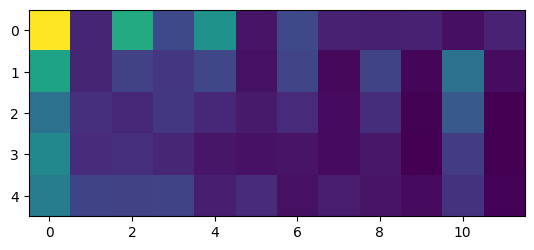

In [19]:
gm, gstd, wm = gradient_norms.collected_norms
print(f"grad_means: {gm.shape}, grad_stddevs: {gstd.shape}, weight_means: {wm.shape}")
plt.imshow(gm)

means: (5, 12), stddevs: (5, 12)


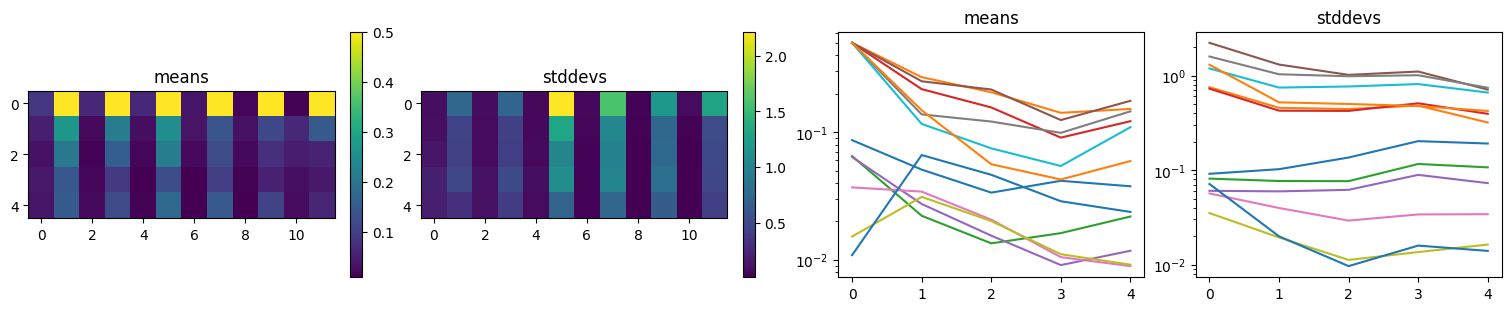

In [20]:
means, stddevs = gradient_norms.normalized_stats
print(f"means: {means.shape}, stddevs: {stddevs.shape}")

plt.figure(figsize=(15,3), layout='constrained')

plt.subplot(1,4,1)
plt.title("means")
plt.imshow(means)
plt.colorbar()

plt.subplot(1,4,2)
plt.title("stddevs")
plt.imshow(stddevs)
plt.colorbar()

plt.subplot(1,4,3)
plt.title("means")
plt.plot(means)
plt.yscale('log')

plt.subplot(1,4,4)
plt.title("stddevs")
plt.plot(stddevs)
plt.yscale('log')

plt.show()

means: (5, 6), stddevs: (5, 6), layers: [0, 1, 2, 3, 4, 5]


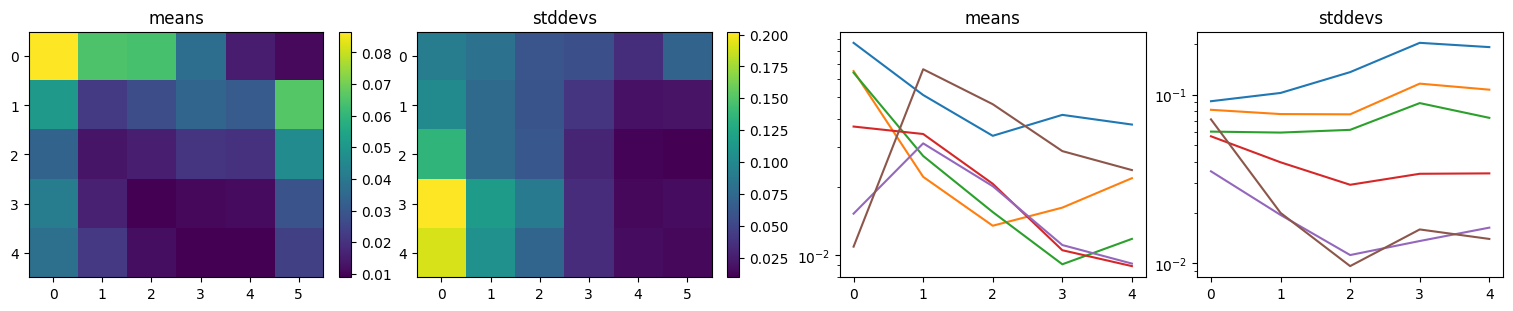

In [22]:
means, stddevs = gradient_norms.normalized_stats_by_layer
l_indices = gradient_norms.normalized_stats_layers
print(f"means: {means.shape}, stddevs: {stddevs.shape}, layers: {l_indices}")

plt.figure(figsize=(15,3), layout='constrained')

plt.subplot(1,4,1)
plt.title("means")
plt.imshow(means)
plt.colorbar()

plt.subplot(1,4,2)
plt.title("stddevs")
plt.imshow(stddevs)
plt.colorbar()

plt.subplot(1,4,3)
plt.title("means")
plt.plot(means)
plt.yscale('log')

plt.subplot(1,4,4)
plt.title("stddevs")
plt.plot(stddevs)
plt.yscale('log')

plt.show()

All layer names:           ['dense_12', 'dense_13', 'dense_14', 'dense_15', 'dense_16', 'dense_17']
Filtered layer indices:    [0, 1, 2, 3, 4, 5]
Filtered layer names:      ['dense_12', 'dense_13', 'dense_14', 'dense_15', 'dense_16', 'dense_17']
Filtered variable indices: [0, 2, 4, 6, 8, 10]
means: (5, 6), stddevs: (5, 6), layers: [0, 1, 2, 3, 4, 5]


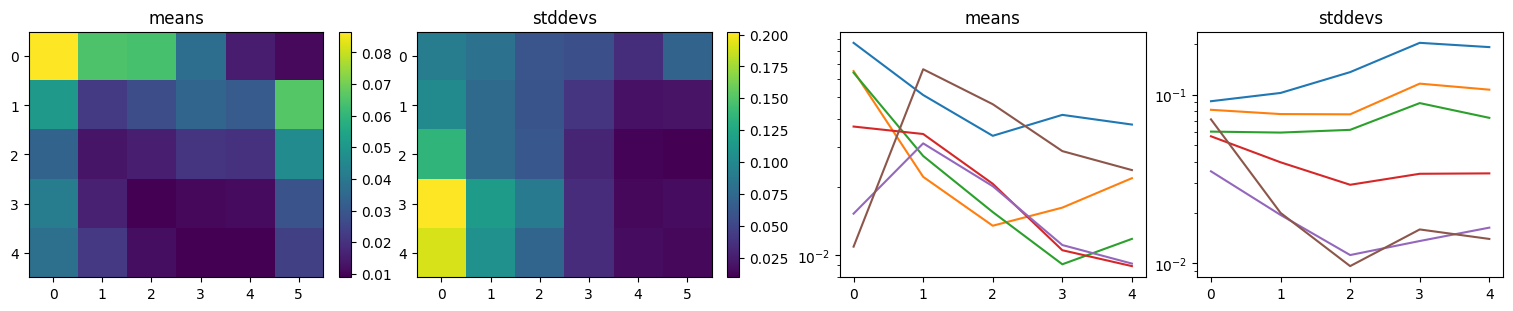

In [23]:
# Instead, picking variables by skipping Dropout and BatchNorm layers (BatchNorm has trainable variables, which might mess up the cleanliness of the results)
print(f"All layer names:           {[layer.name for layer in model.layers]}")
print(f"Filtered layer indices:    {layer_indices_of_interest(model)}")
print(f"Filtered layer names:      {[model.layers[l_idx].name for l_idx in layer_indices_of_interest(model)]}")
print(f"Filtered variable indices: {trainable_variable_indices_of_interest(model)}")

filtered_variable_indices = trainable_variable_indices_of_interest(model)
means, stddevs = gradient_norms.normalized_stats
means = means[:, filtered_variable_indices]
stddevs = stddevs[:, filtered_variable_indices]
print(f"means: {means.shape}, stddevs: {stddevs.shape}, layers: {l_indices}")


plt.figure(figsize=(15,3), layout='constrained')

plt.subplot(1,4,1)
plt.title("means")
plt.imshow(means)
plt.colorbar()

plt.subplot(1,4,2)
plt.title("stddevs")
plt.imshow(stddevs)
plt.colorbar()

plt.subplot(1,4,3)
plt.title("means")
plt.plot(means)
plt.yscale('log')

plt.subplot(1,4,4)
plt.title("stddevs")
plt.plot(stddevs)
plt.yscale('log')

plt.show()